In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('result_data.csv')
df.head()

,Unnamed: 0,track_id,DateTime,latitude,longitude,altitude,temp,region,water_dist,building_dist,green_dist,water_area,building_area,green_area,season,hour
0,0,1,2022-03-23 03:47:32,28.526319,77.205764,233.448227,21.0,Region 1,483.748137,17.263341,219.293124,9.614001,1361.365668,9.068051,Весна,3
1,1,1,2022-03-23 03:47:33,28.526304,77.205761,233.366989,16.0,Region 1,484.978274,18.888186,220.963695,9.614001,1361.576094,9.068051,Весна,3
2,2,1,2022-03-23 03:47:34,28.526298,77.205760,233.334747,25.0,Region 1,485.481786,19.533009,221.631384,9.614001,1353.855885,9.068051,Весна,3
3,3,1,2022-03-23 03:47:35,28.526288,77.205757,233.280121,19.0,Region 1,486.250814,20.664223,222.748454,9.614001,1350.015010,9.068051,Весна,3
4,4,1,2022-03-23 03:47:36,28.526277,77.205755,233.228973,21.0,Region 1,487.167542,21.860118,223.973323,9.614001,1350.783267,9.068051,Весна,3


In [4]:
df.columns

Index(['Unnamed: 0', 'track_id', 'DateTime', 'latitude', 'longitude',
       'altitude', 'temp', 'region', 'water_dist', 'building_dist',
       'green_dist', 'water_area', 'building_area', 'green_area', 'season',
       'hour'],
      dtype='object')

## Разметка зон подтопления и зон повышенной пожарной опасности по значениям характеристик маршрута

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366000 entries, 0 to 365999
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     366000 non-null  int64  
 1   track_id       366000 non-null  int64  
 2   DateTime       366000 non-null  object 
 3   latitude       366000 non-null  float64
 4   longitude      366000 non-null  float64
 5   altitude       366000 non-null  float64
 6   temp           366000 non-null  float64
 7   region         366000 non-null  object 
 8   water_dist     366000 non-null  float64
 9   building_dist  366000 non-null  float64
 10  green_dist     366000 non-null  float64
 11  water_area     366000 non-null  float64
 12  building_area  366000 non-null  float64
 13  green_area     366000 non-null  float64
 14  season         366000 non-null  object 
 15  hour           366000 non-null  int64  
dtypes: float64(10), int64(3), object(3)
memory usage: 44.7+ MB


In [5]:
df.describe()

,Unnamed: 0,track_id,latitude,longitude,altitude,temp,water_dist,building_dist,green_dist,water_area,building_area,green_area,hour
count,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000
mean,182999.500000,1.176000,28.522407,77.207817,235.893438,6.579416,37.032324,18.853602,351.541768,-0.225178,1612.494443,2555.934088,11.625407
std,105655.243599,0.380821,0.001758,0.002496,0.860400,13.032127,135.672690,15.673433,109.022040,2.761093,185.497539,1826.317186,6.827085
min,0.000000,1.000000,28.520251,77.202964,233.063141,-17.180000,-1.000000,0.208151,-1.000000,-1.000000,1231.721079,-1.000000,0.000000
25%,91499.750000,1.000000,28.520626,77.205768,235.302273,1.290000,-1.000000,7.729536,300.388912,-1.000000,1559.912310,9.068051,6.000000
50%,182999.500000,1.000000,28.522185,77.207825,235.846839,7.770000,-1.000000,13.600871,368.918403,-1.000000,1655.652929,3102.917350,12.000000
75%,274499.250000,1.000000,28.523570,77.210253,236.527572,16.760000,-1.000000,23.501063,425.338629,-1.000000,1715.993855,3102.917350,17.000000
max,365999.000000,2.000000,28.526319,77.211323,237.907379,29.000000,563.530345,73.670807,523.376024,9.614001,1923.185580,7450.647125,23.000000


In [11]:
df.season.unique()

array(['Весна', 'Зима', 'Лето', 'Осень'], dtype=object)

Определим возможное затопление как близость к водоемам и его размер (площадь), а также высота над уровнем моря. Стоит также учесть сезон - взять осень и весну (например, весной риск подтопления выше из-за таяния снега)

Зону пожарной опасности буду опрелять как наличие полей рядом с точкой маршрута, повышенную температуру воздуха и сезон - лето

In [4]:
def water_and_fire_risk(row):
    water_risk = (row['water_dist'] < 100) and (row['altitude'] < 235) and (row['season'] in ['Весна', 'Лето'])
    fire_risk = (row['green_dist'] < 70) and (row['temp'] > 20) and (row['season'] == 'Лето')

    if fire_risk:
        return 2
    elif water_risk:
        return 1
    else:
        return 0

In [5]:
water_and_fire_risk_arr = []
for index,row in df.iterrows():
    water_and_fire_risk_arr.append(water_and_fire_risk(row))

Результаты разметки

In [6]:
df['water_and_fire_risk'] = water_and_fire_risk_arr
df['water_and_fire_risk'].value_counts() #распределение точек по классам

water_and_fire_risk
0    354710
1      9435
2      1855
Name: count, dtype: int64

## Кластеризация зон подтопления и зон повышенной пожарной опасности по значениям характеристик маршрута

In [7]:
from sklearn.preprocessing import OneHotEncoder
X = df[['water_dist', 'water_area', 'altitude', 
            'green_dist', 'green_area', 'temp',
            'building_dist', 'building_area', 'season']]

#кодируем признак сезон
ohe_season = OneHotEncoder()
seasons = ohe_season.fit_transform(X[['season']])
seasons.toarray()

array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]])

In [8]:
seasons_df=pd.DataFrame(seasons.toarray(), columns=ohe_season.get_feature_names_out())
X = pd.concat([X.drop(['season'],axis=1),seasons_df],axis=1)
X.head()

,water_dist,water_area,altitude,green_dist,green_area,temp,building_dist,building_area,season_Весна,season_Зима,season_Лето,season_Осень
0,483.748137,9.614001,233.448227,219.293124,9.068051,21.0,17.263341,1361.365668,1.0,0.0,0.0,0.0
1,484.978274,9.614001,233.366989,220.963695,9.068051,16.0,18.888186,1361.576094,1.0,0.0,0.0,0.0
2,485.481786,9.614001,233.334747,221.631384,9.068051,25.0,19.533009,1353.855885,1.0,0.0,0.0,0.0
3,486.250814,9.614001,233.280121,222.748454,9.068051,19.0,20.664223,1350.015010,1.0,0.0,0.0,0.0
4,487.167542,9.614001,233.228973,223.973323,9.068051,21.0,21.860118,1350.783267,1.0,0.0,0.0,0.0


In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df['water_and_fire_cluster'] = kmeans.fit_predict(X_scaled)

In [11]:
df['water_and_fire_cluster'].value_counts()

water_and_fire_cluster
1    253998
0     85284
2     26718
Name: count, dtype: int64

Сделаем профилирование кластеров

In [37]:
df.head()

,Unnamed: 0,track_id,DateTime,latitude,longitude,altitude,temp,region,water_dist,building_dist,green_dist,water_area,building_area,green_area,season,hour,water_and_fire_risk,water_and_fire_cluster
0,0,1,2022-03-23 03:47:32,28.526319,77.205764,233.448227,21.0,Region 1,483.748137,17.263341,219.293124,9.614001,1361.365668,9.068051,Весна,3,0,2
1,1,1,2022-03-23 03:47:33,28.526304,77.205761,233.366989,16.0,Region 1,484.978274,18.888186,220.963695,9.614001,1361.576094,9.068051,Весна,3,0,2
2,2,1,2022-03-23 03:47:34,28.526298,77.205760,233.334747,25.0,Region 1,485.481786,19.533009,221.631384,9.614001,1353.855885,9.068051,Весна,3,0,2
3,3,1,2022-03-23 03:47:35,28.526288,77.205757,233.280121,19.0,Region 1,486.250814,20.664223,222.748454,9.614001,1350.015010,9.068051,Весна,3,0,2
4,4,1,2022-03-23 03:47:36,28.526277,77.205755,233.228973,21.0,Region 1,487.167542,21.860118,223.973323,9.614001,1350.783267,9.068051,Весна,3,0,2


In [12]:
pd.set_option('display.max_rows', 80)
num_df = df.select_dtypes(include='number')
num_df.groupby('water_and_fire_cluster', observed=True).agg(['count','mean', 'std']).T

water_and_fire_cluster                 0              1              2
Unnamed: 0          count   85284.000000  253998.000000   26718.000000
                    mean   196222.554477  181968.631470  150591.519126
                    std     70705.317995  115928.227185   87061.939781
track_id            count   85284.000000  253998.000000   26718.000000
                    mean        1.189860       1.189860       1.000000
                    std         0.392192       0.392191       0.000000
latitude            count   85284.000000  253998.000000   26718.000000
                    mean       28.522131      28.522131      28.525908
                    std         0.001512       0.001512       0.000248
longitude           count   85284.000000  253998.000000   26718.000000
                    mean       77.207983      77.207983      77.205710
                    std         0.002518       0.002518       0.000028
altitude            count   85284.000000  253998.000000   26718.000000
                    mean      236.009067     236.009067     234.425106
                    std         0.742496       0.742494       0.902481
temp                count   85284.000000  253998.000000   26718.000000
                    mean       22.793789       1.165372       6.292328
                    std         3.857776      10.198019      13.130244
water_dist          count   85284.000000  253998.000000   26718.000000
                    mean       -1.000000      -1.000000     519.990745
                    std         0.000000       0.000000      23.113368
building_dist       count   85284.000000  253998.000000   26718.000000
                    mean       18.758401      18.758401      20.062521
                    std        16.237526      16.237462       3.940296
green_dist          count   85284.000000  253998.000000   26718.000000
                    mean      358.354862     358.354862     265.024799
                    std       110.120628     110.120200      27.484439
water_area          count   85284.000000  253998.000000   26718.000000
                    mean       -1.000000      -1.000000       9.614001
                    std         0.000000       0.000000       0.000000
building_area       count   85284.000000  253998.000000   26718.000000
                    mean     1638.327256    1638.327256    1284.453112
                    std       166.873639     166.872989      40.767574
green_area          count   85284.000000  253998.000000   26718.000000
                    mean     2756.496354    2756.496354       9.068051
                    std      1745.591843    1745.585045       0.000000
hour                count   85284.000000  253998.000000   26718.000000
                    mean       11.284813      11.733415      11.685792
                    std         6.685274       6.872439       6.807161
water_and_fire_risk count   85284.000000  253998.000000   26718.000000
                    mean        0.098518       0.018673       0.000000
                    std         0.363752       0.135369       0.000000

По результатам кластеризации кластер 0 - повышенная пожароопасность (высокая температура, большая площадь полей),кластер 1 - нет опасных зон, кластер 2 - зоны возможного подтопления (площадь водоемов в ближайших 500 метрах больше чем в лругих кластерах)

In [13]:
#приведем кластеры к таким же меткам, как были при разметке
df['water_and_fire_cluster']=df['water_and_fire_cluster'].map({0:2,1:0,2:1})

Сравним оба подхода через метрику силуэт

In [16]:
from sklearn.metrics import silhouette_score

silhouette_label = silhouette_score(X[:10000], df['water_and_fire_risk'][:10000])
silhouette_label

np.float64(-0.5170781521551382)

In [17]:
silhouette_cluster = silhouette_score(X[:1000], df['water_and_fire_cluster'][:1000])
silhouette_cluster

np.float64(0.40117251201795284)

Сожмем пространство признаков для визуального анализа рапределения данных по классам

In [18]:
X.head()

,water_dist,water_area,altitude,green_dist,green_area,temp,building_dist,building_area,season_Весна,season_Зима,season_Лето,season_Осень
0,483.748137,9.614001,233.448227,219.293124,9.068051,21.0,17.263341,1361.365668,1.0,0.0,0.0,0.0
1,484.978274,9.614001,233.366989,220.963695,9.068051,16.0,18.888186,1361.576094,1.0,0.0,0.0,0.0
2,485.481786,9.614001,233.334747,221.631384,9.068051,25.0,19.533009,1353.855885,1.0,0.0,0.0,0.0
3,486.250814,9.614001,233.280121,222.748454,9.068051,19.0,20.664223,1350.015010,1.0,0.0,0.0,0.0
4,487.167542,9.614001,233.228973,223.973323,9.068051,21.0,21.860118,1350.783267,1.0,0.0,0.0,0.0


In [19]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2) #рса на два компонента
pca.fit(X) #обучаем
reduced = pca.transform(X)

In [21]:
pca_df=pd.DataFrame(reduced)
pca_df.columns=['x','y']
pca_df['target_labels']=df['water_and_fire_risk']
pca_df['target_clusters']=df['water_and_fire_cluster']

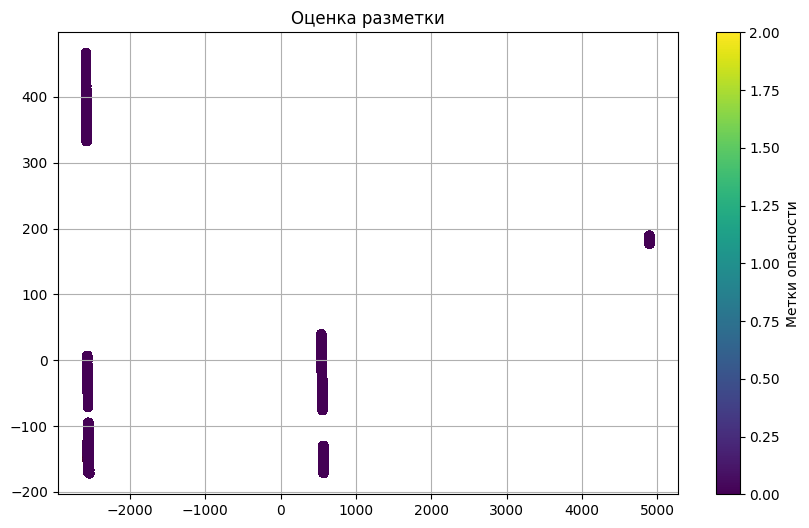

In [25]:
#визуализация для разметки
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(pca_df['x'], pca_df['y'], c=pca_df['target_labels'], cmap='viridis')
plt.colorbar(label='Метки опасности')
plt.title('Оценка разметки')
plt.grid(True)
plt.show()

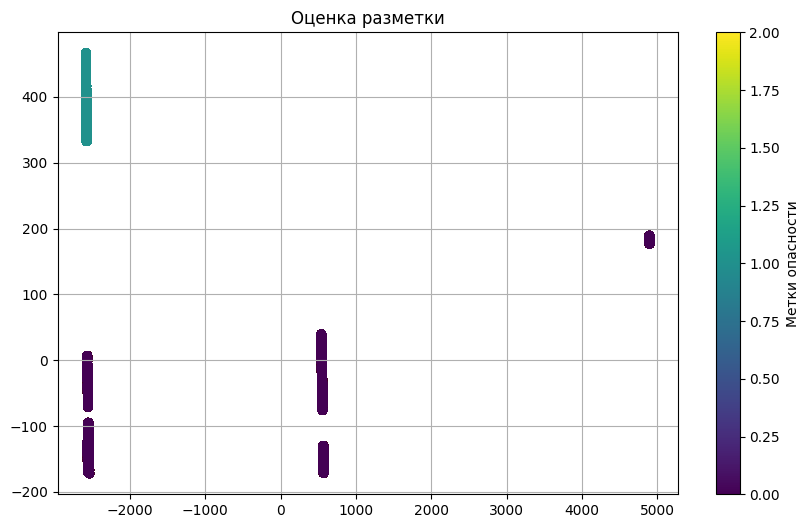

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_df['x'], pca_df['y'], c=pca_df['target_clusters'], cmap='viridis')
plt.colorbar(label='Метки опасности')
plt.title('Оценка разметки')
plt.grid(True)
plt.show()

Благодаря оценке по метрике силует и визуальному анализу - лучшим алгоритмом для распределения на опасные зоны является кластеризация через Kmeans (метрика выше, на графике более четко видно разбиение на кластеры)

## Разметка уровня сложности эвакуации

In [ ]:
"""
2 - высокий уровень сложности
1 - средний
0 - низкий

"""

РУСЛАН ТУТ НАДО НАСТРОИТЬ ДЛЯ ТВОЕГО ДАТАСЕТА
def lvl_difficulty_evac(row):
    if row['water_and_fire_cluster'] in [1, 2]:
            return 2
    if row['water_dist'] < 50 or row['building_dist'] < 50 or row['green_dist'] < 50: 
        return 2 
    elif row['water_dist'] < 100 or row['building_dist'] < 100 or row['green_dist'] < 100:
        return 1
    else:
        return 0

In [29]:
lvl_arr = []
for index,row in df.iterrows():
    lvl_arr.append(lvl_difficulty_evac(row))

In [30]:
df['evac_difficulty_lvl'] = lvl_arr
df['evac_difficulty_lvl'].value_counts() #распределение точек по классам

evac_difficulty_lvl
2    366000
Name: count, dtype: int64

ПОВТОРИТЬ ШАГИ ИЗ ПЕРВОЙ ЗАДАЧИ И ВЫБРАТЬ ЛУЧШИЙ АЛГОРИТМ
ИТОГОВЫЕ МЕТКИ СОХРАНИТЬ В БАЗУ!